## Machine Learning Project

**Context**

Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc.

He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies.

Bob wants to find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve this problem.

In this problem you do not have to predict actual price but a price range indicating how high the price is

**Import Libraries**

Import necessary libraries and modules, including ```pandas```, ```numpy```, and several ```sklearn``` components for data preprocessing and modeling.

In [1]:
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, Normalizer, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import loguniform, beta, uniform

from mlxtend.feature_selection import SequentialFeatureSelector

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

**Load Dataset**

The dataset ```mobileprices.csv``` is loaded using ```pandas```, and basic information about the dataset structure and types is displayed.

In [2]:
data = pd.read_csv('mobileprices.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

**Display Dataset**

Dislpaying the dataset head, first look to columns and values

In [3]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


**Null values**

To controll missing value in the dataset, this command displays the proportion of ```NaN``` Values over all samples for each column

In [4]:
data.isnull().sum(axis=0)/data.shape[0]

battery_power    0.0
blue             0.0
clock_speed      0.0
dual_sim         0.0
fc               0.0
four_g           0.0
int_memory       0.0
m_dep            0.0
mobile_wt        0.0
n_cores          0.0
pc               0.0
px_height        0.0
px_width         0.0
ram              0.0
sc_h             0.0
sc_w             0.0
talk_time        0.0
three_g          0.0
touch_screen     0.0
wifi             0.0
price_range      0.0
dtype: float64

**Data general info**

The command ```data.info()``` gives a general recap of the information of the dataset, giving useful insights like the number of rows, the number of columns, the names of the columns, the datatype of each column...

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

**Target column**

We've seen that there are no missing values, and that all datatypes of the columns are ```int64``` and ```float64```, which means that a we won't need to perform much feature engineering.
Let's explore in particular the target column

In [6]:
data['price_range'].unique()

array([1, 2, 3, 0])

**Setting features and target columns**

The target column ```'price_range'``` has 4 possible value: 

```0``` = low price range,

```1``` = mid price range,

```2``` = high price range,

```3``` = very high price range.

```0``` and ```1``` will be mapped to ```0```, indicating a low range price, while ```2``` and ```3``` will be mapped to ```1```, indicating a high range price. Done witih the function ```map()```

The other columns will be the features on which the model will work on

In [7]:
X = data.drop(columns=['price_range'])
y = data['price_range'].map({0 : 0, 1 : 0, 2 : 1, 3 : 1 })


**Configurations of transformers, samplers, dimensionality reducers, classifiers**

The variables ```trans_configs```, ```sampler_configs```, ```dim_reduction_configs```, ```classifier_configs```, contain a list of dictionaries.

Each dictionary contains a possible transformer, sampler, dimensionality reducer, classifier, with respective possible parameters.

These are NOT all the transformers, samplers, dimensionality reducers, classifiers, there are only the ones that could perform better making predictions on the target column of this dataset (relying on the other features).

In [8]:
trans_configs = [
        {'trans': [None]},
        {'trans': [StandardScaler()]},
        {'trans': [Normalizer()]}
    ]
sampler_configs = [
        {'sampler': [None]},
        {'sampler': [SMOTE()], 'sampler__sampling_strategy': ['minority', 1.2, 0.9, 0.7]},
        {'sampler': [RandomOverSampler()], 'sampler__sampling_strategy': ['minority', 0.9, 0.7, 0.5]}
    ]
dim_reduction_configs = [
        {'dim_reduction': [None]},
        {'dim_reduction': [PCA()], 'dim_reduction__n_components': [0.5, 0.7, 0.9]},
        {'dim_reduction': [LinearDiscriminantAnalysis()]},
        {'dim_reduction': [SequentialFeatureSelector(estimator=Perceptron(), cv = None, scoring = 'f1')], 'dim_reduction__estimator': [Perceptron(), LogisticRegression()], 'dim_reduction__k_features' : [5,7,10]}
    ]
classifier_configs = [
        {'classifier': [Perceptron()], 'classifier__eta0' : loguniform(0.001,100), 'classifier__max_iter': [1,5,10,15,50,100], 'classifier__class_weight' : [None, 'balanced']},
        {'classifier': [LogisticRegression(solver='saga')], 'classifier__C' : loguniform(0.001,100), 'classifier__penalty': ['l1','l2'], 'classifier__class_weight' : [None, 'balanced']},
        {'classifier': [KNeighborsClassifier()], 'classifier__n_neighbors': [3,5,7,9]},
        {'classifier' : [RandomForestClassifier()], 'classifier__n_estimators' : [10,50,100,500]}
    ]

**Randomized search Function**

Using ```itertool.product``` we can get a list of all possibe combos of transformer, sampler, dimensionality reducer, classifier.

For a certain combo in the list of all possible combos there will be different configurations of parameters.

Using ```itertool.chain.from_iterable``` each configuration is converted into a dictionary, to be suitale for ```RandomizedSearcCV``` ```param_distributions``` parameter.

The function starts a randomized search that has ```param_distribution=param_grid```, that will search for the best evalued model

In [9]:
def randomized_search(pipeline, X, y):

    param_grid = [dict(itertools.chain.from_iterable(config.items() for config in combo))
                  for combo in itertools.product(trans_configs, sampler_configs, dim_reduction_configs, classifier_configs)]
    
    print("Possible configurations:", len(param_grid))

    rs = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=len(param_grid)*3, scoring='f1', n_jobs=-1, cv=5)

    return rs

**Candidates function**

This function receives as input a ```RandomizedSearchCV``` object, the train dataset (divided in features and target column) and the test dataset (divided in features and target column)

and gives as output two matrices:

```CANDIDATES```: contains the five best model candidates (one per each row)

```F1_SCORES```: contains the respective ```f1_scores``` (on train and test) of the candidates (respective ```f1_train``` and ```f1_test``` in each row)

First the function performs 5-fold cross-validation on the ```RandomizedSearchCV``` object received as input (on training set).

```scores``` = a dictionary containing cross-validation results, including the estimator (fitted models) and the f1_score

The candidates are the 5 estimators computed using cross-validation

The f1_scores for train and test datasets are computed after fitting each best estimator of each fold on the train dataset

In [10]:
def candidates(randsearch, X_train, X_test, y_train, y_test):
    
    scores = cross_validate(randsearch, X_train, y_train, scoring='f1', cv = 5, return_estimator=True, verbose=3) #3 minutes

    CANDIDATES = []

    for index, estimator in enumerate(scores['estimator']):
        trans = estimator.best_estimator_.get_params()['trans']
        sampler = estimator.best_estimator_.get_params()['sampler']
        dim_reduction = estimator.best_estimator_.get_params()['dim_reduction']
        classifier = estimator.best_estimator_.get_params()['classifier']
        score = scores['test_score'][index]
        candidate = [trans,sampler,dim_reduction,classifier,score]
        CANDIDATES.append(candidate)
    
    F1_SCORES= []

    for estimator in scores['estimator']:
        estimator.best_estimator_.fit(X_train, y_train)
        pred_train = estimator.best_estimator_.predict(X_train)
        pred_test = estimator.best_estimator_.predict(X_test)
        f1_train = f1_score(y_train, pred_train)
        f1_test = f1_score(y_test, pred_test)
        f1_candidate = [f1_train, f1_test]
        F1_SCORES.append(f1_candidate)

    return CANDIDATES, F1_SCORES

**Tuning Parameters function**

This function receive as input a ```pipeline``` and gives as output the usable parameters for the transformer, for the sampler, for the dimensionality reducer and for the classifier

In [11]:
def tuning_params(pipeline):
    params = {}

    for trans in trans_configs:
        if (trans is None) or isinstance(pipeline[0], type(trans['trans'][0])):
            params.update({key: value for key, value in trans.items() if key != 'trans'})

    for sampler in sampler_configs:
        if (sampler is None) or isinstance(pipeline[1], type(sampler['sampler'][0])):
            params.update({key: value for key, value in sampler.items() if key != 'sampler'})

    for dim_reduction in dim_reduction_configs:
        if (dim_reduction is None) or isinstance(pipeline[2], type(dim_reduction['dim_reduction'][0])):
            params.update({key: value for key, value in dim_reduction.items() if key != 'dim_reduction'})

    for classifier in classifier_configs:
        if isinstance(pipeline[3], type(classifier['classifier'][0])):
            params.update({key: value for key, value in classifier.items() if key != 'classifier'})

    return params

**Split the dataset**

Using ```train_test_split```, we split ```X```, ```y``` in ```X_train```, ```X_test```, ```y_train```, ```y_test```

```test_size=0.2``` specifies the proportion: the 20% of the data will be used for test, and the remaining 80% for train

```stratify=y``` keeps the same class distribution in the training and test sets match the original 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

**Model pipeline**

```IMBPipeline``` is a specialized pipeline, from imbalanced-learn library, for handling imbalanced datasets. It applies, sequentially, data transformation, sampling techniques, dimensionality reduction, and a classifier

This pipeline won't be our final estimator, this is just one of the possible configurations

In [13]:
guess_pipeline = IMBPipeline([
    ('trans', StandardScaler()),
    ('sampler', SMOTE()),
    ('dim_reduction', LinearDiscriminantAnalysis()),
    ('classifier', RandomForestClassifier())
])

**Performing Randomized search function**

Performing ```randomized_search()``` function on the ```guess_pipeline``` we just defined, on ```X_train``` and ```y_train```

In [14]:
rs = randomized_search(guess_pipeline, X_train, y_train)

Possible configurations: 144


**Performing Candidates function**

The ```candidates()``` function is used on the previous cell's ```RandomizedSearchCV```, on ```X_train```, ```X_test```, ```y_train```, ```y_test```



In [15]:
CANDIDATES, F1_SCORES = candidates(rs, X_train, X_test, y_train, y_test)

[CV] END ......................................., score=0.975 total time= 1.4min
[CV] END ......................................., score=0.984 total time= 1.7min
[CV] END ......................................., score=0.997 total time= 1.3min
[CV] END ......................................., score=0.981 total time= 1.3min
[CV] END ......................................., score=0.991 total time= 1.8min


**From matrix to pandas dataframe**

```CANDIDATES```, ```F1_SCORES``` matrices are transformed in ```df_candidates```, ```df_f1_scores``` pandas dataframes: this enhances readability and versatility

In [16]:
df_candidates = pd.DataFrame(CANDIDATES, columns=['Trans','Sampler','DimReduction','Classifier','F1Score'])
df_candidates.head()

,Trans,Sampler,DimReduction,Classifier,F1Score
0,StandardScaler(),RandomOverSampler(sampling_strategy='minority'),None,LogisticRegression(C=np.float64(44.65696018374...,0.974522
1,None,None,PCA(n_components=0.9),LogisticRegression(C=np.float64(4.418076450561...,0.984326
2,StandardScaler(),None,"SequentialFeatureSelector(cv=None, estimator=L...",LogisticRegression(C=np.float64(1.653560139941...,0.996885
3,StandardScaler(),SMOTE(sampling_strategy='minority'),"SequentialFeatureSelector(cv=None, estimator=P...",LogisticRegression(C=np.float64(1.901667594223...,0.981481
4,StandardScaler(),None,"SequentialFeatureSelector(cv=None, estimator=L...",LogisticRegression(C=np.float64(67.84152476573...,0.990654


In [17]:
df_scores = pd.DataFrame(F1_SCORES, columns=['F1Train','F1Test'])
df_scores.head()

,F1Train,F1Test
0,0.994386,0.994975
1,0.987453,0.989899
2,0.987484,0.989950
3,0.986850,0.987469
4,0.993750,0.987406


**Best candidate index**

Now that ```df_candidates``` and ```df_scores``` are dataframes, and that the estimator candidate and its f1_scores have the same index, we can relate them

To choose between the five estimators we check their f1 train and test scores, giving more importance to the f1 test score

In [18]:
weights = [0.2, 0.8]
weighted_sum = df_scores['F1Train'] * weights[0] + df_scores['F1Test'] * weights[1]
best_candidate_index = int(weighted_sum.argmax())

**Best model pipeline**

We use the configuration we just found (i.e. the ```best_candidate_index``` row of the ```df_candidates``` dataframe) to construct a new pipeline

In [19]:
best_model_pipeline = IMBPipeline([
    ('trans', df_candidates['Trans'][best_candidate_index]),
    ('sampler', df_candidates['Sampler'][best_candidate_index]),
    ('dim_reduction', df_candidates['DimReduction'][best_candidate_index]),
    ('classifier', df_candidates['Classifier'][best_candidate_index])
])

**Calling tuning_params on best_model_pipeline, RandomizedSearchCV on best_model_pipeline**

We got a best model pipeline, now we define a new ```RandomizedSearchCV``` object to get the best configuration of the parameters of this pipeline

For the params_distribution we call the function ```tuning_param()``` on the ```best_model_pipeline```

```cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3``` is a cross validation strategy that ensures that stratification is preserved in each fold

In [20]:
params = tuning_params(best_model_pipeline)

In [21]:
rs_best = RandomizedSearchCV(
    estimator = best_model_pipeline,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3),
    n_iter=50,
    scoring='f1'
)

**PREDICT**

After we did the ```rs_best``` ```RandomizedSearchCV```, we fit this randomized search on the train dataset, and we get our ```final_estimator``` by calling the attribute ```best_estimator_``` on the the randomized search

In [22]:
rs_best.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('trans', StandardScaler()),
                                             ('sampler',
                                              RandomOverSampler(sampling_strategy='minority')),
                                             ('dim_reduction', None),
                                             ('classifier',
                                              LogisticRegression(C=np.float64(44.656960183744374),
                                                                 solver='saga'))]),
                   n_iter=50,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AC3D3908C0>,
                                        'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__penalty': ['l1', 'l2'],
                                        'sampler__sampling_strategy': ['minority',
                                                                       0.9, 0.7,
                                                                       0.5]},
                   scoring='f1')

In [23]:
final_estimator = rs_best.best_estimator_
final_estimator

Pipeline(steps=[('trans', StandardScaler()),
                ('sampler', RandomOverSampler(sampling_strategy='minority')),
                ('dim_reduction', None),
                ('classifier',
                 LogisticRegression(C=np.float64(0.2497603472346407),
                                    class_weight='balanced', penalty='l1',
                                    solver='saga'))])

Now we can predict on ```X_test```

In [24]:
y_pred = final_estimator.predict(X_test)

**SCORES**

Too see how the ```final_estimator``` is performing, we can compute some scores:

```f1_score``` is the harmonic mean of precision and recall

```roc_auc_score``` is the area under the ROC curve

In [25]:
f1score = f1_score(y_test, y_pred)
print("F1 score:", f1score)
rocauc = roc_auc_score(y_test, y_pred)
print("roc_auc_score:", rocauc)

F1 score: 0.9874055415617129
roc_auc_score: 0.9874999999999999


**Visualization**

Now, we can visualize the ```learning_curve``` and the ```validation_curve``` to quantify the bias/variance trade-off as a function of the size of the training set and the variation of the hyperparameter $C$, for the case of ```Logistic Regression```.

In [26]:
train_sizes, train_scores, test_scores = learning_curve(final_estimator,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = False)

(0.8, 1.02)

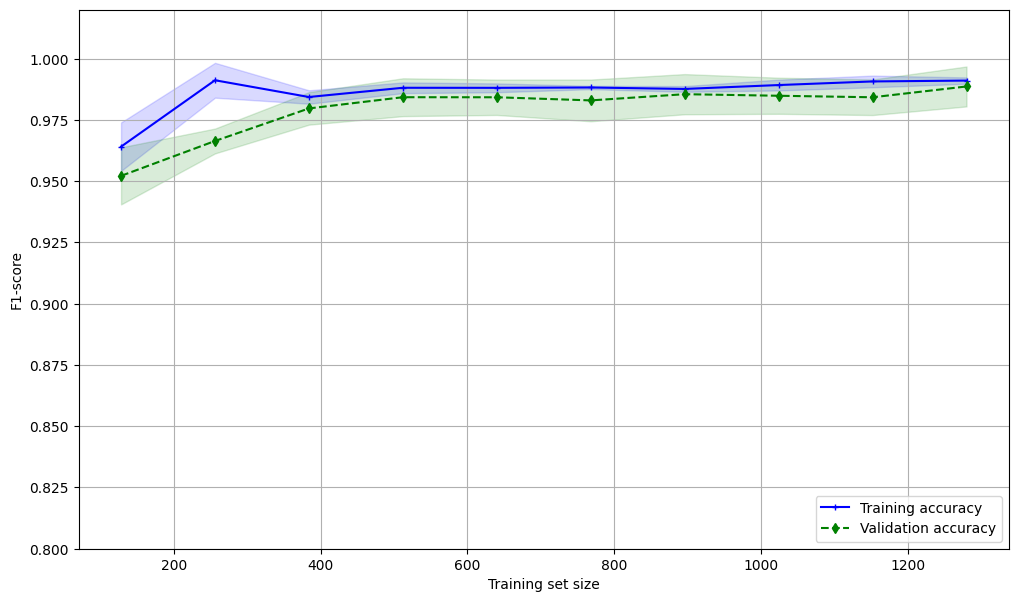

In [27]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training accuracy')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation accuracy')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.80, 1.02])

In [28]:
range_C = [0.001,0.01,0.1,1,10,100]
train_scores, test_scores = validation_curve(final_estimator,
        X=X_train, 
        y=y_train, 
        param_range=
        range_C, 
        param_name='classifier__C',
        cv=5, 
        n_jobs=-1, 
        scoring='f1'
)

(0.05, 100)

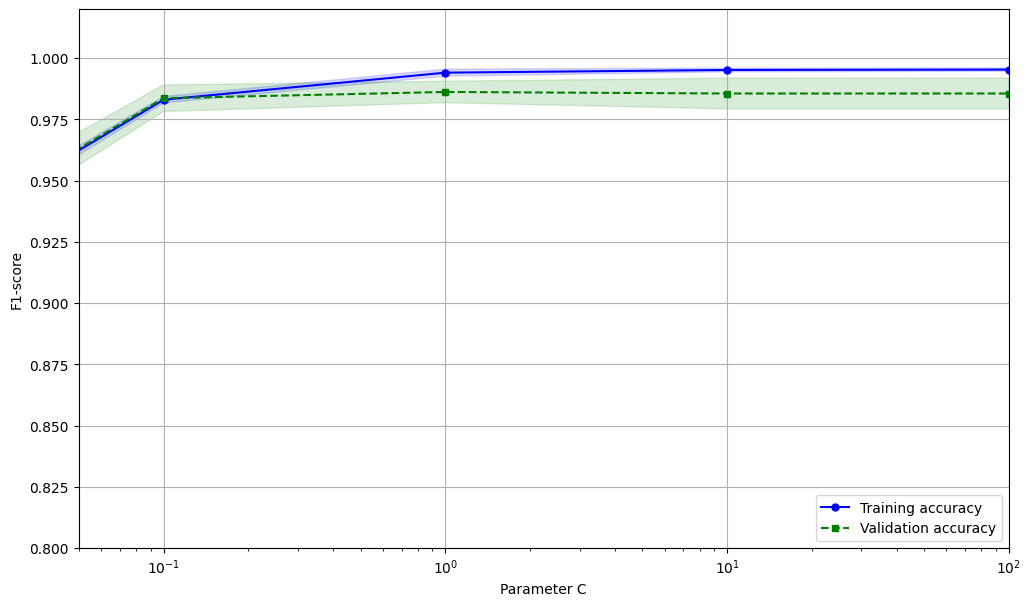

In [29]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(range_C, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.8, 1.02])
ax.set_xscale('log')
ax.set_xlim([0.05,100])